# Relatividad y Gravitación
## Prof. Jorge I. Zuluaga

### Cuaderno de Clase: cinemática en el espacio-tiempo

In [ ]:
#!pip3 install -Uq numpy scipy einsteinpy matplotlib

In [1]:
import numpy as np

Vamos a escribir un solucionador de la ecuación de movimiento:

$$
\frac{d^2 \tilde{x}_L}{d\tau^2} = \tilde{A}_L(\tilde{x}_L,\tau)
$$

Equivale:
$$
\frac{d\tilde{x}_L}{d\tau} = \tilde{U}\\
\frac{d\tilde{U}_L}{d\tau} = \tilde{A}_L(\tilde{x}_L,\tau)
$$

In [3]:
def edm_espacio_tiempo(tau, Ys, alpha):
    # Ys: contiene todas las variables del problema
    #  t, x, y, z, Ut, Ux, Uy, Uz
    T, x, y, z, Ut, Ux, Uy, Uz = Ys

    # Ecuaciones de movimiento
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz

    # ¿Cuánto valen las componentes de A?
    # La aceleración propia
    Apropia = np.array([0, alpha, 0, 0])

    # La aceleración en el sistema de coordenadas del observador
    gamma = Ut
    beta = Ux / gamma
    Lambda = np.array([
        [gamma, gamma*beta, 0, 0],
        [gamma*beta, gamma, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    Atierra = Lambda @ Apropia 
    # Así es

    dUt_dtau = Atierra[0]
    dUx_dtau = Atierra[1]
    dUy_dtau = Atierra[2]
    dUz_dtau = Atierra[3]

    return dT_dtau, dx_dtau, dy_dtau, dz_dtau, dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau

# Condiciones iniciales 

condiciones einiciales en coordenadas espacio tiempo

In [5]:
c=1 #unidades relativistas
c_SI = 299792458 #m/s
UT= 365.25*86400*c
UL = UT*c_SI
UV= UL/ UT
UA= UL/ UT**2 

In [9]:
t=0
x=0
y=0
z=0 

vx=0
vy=0
vz=0 

UL, UT, UV, UA

(9460730472580800.0, 31557600.0, 299792458.0, 9.499849735087587)

condiciones iniciales esperadas

In [7]:
T= c*t
gamma = 1/ np.sqrt(1- (vx**2 + vy**2 + vz**2)/c**2)
Ut = gamma*c
UX = gamma*vx
UY = gamma*vy
UZ = gamma*vz

Y0 = np.array([T, x, y, z, UT, UX, UY, UZ])

In [8]:
from scipy.integrate import solve_ivp

In [10]:
alpha = 9.8/UA
#tiempo propio
taus=np.linspace(0, 4, 100)
solve_ivp(edm_espacio_tiempo, (taus[0], taus[-1]), Y0, args=(alpha,), t_eval=taus)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.040e-02 ...  3.960e+00  4.000e+00]
        y: [[ 0.000e+00  1.275e+06 ...  9.086e+08  9.473e+08]
            [ 0.000e+00  2.658e+04 ...  8.785e+08  9.172e+08]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 92
     njev: 0
      nlu: 0

Extracion de la solucion

In [ ]:
taus= solucion.t
Ts= solucion.y[0]
xs= solucion.y[1]
ys= solucion.y[2]
zs= solucion.y[3]

Uts= solucion.y[4]
UXs= solucion.y[5]
UYs= solucion.y[6]
UZs= solucion.y[7]

convertir las medidas espaciotemporales en medidas espaciales y temporales 

In [ ]:
ts=Ts/c

gamas= Uts/c
vxs= UXs/gamas
vys= UYs/gamas 
vzs= UZs/gamas

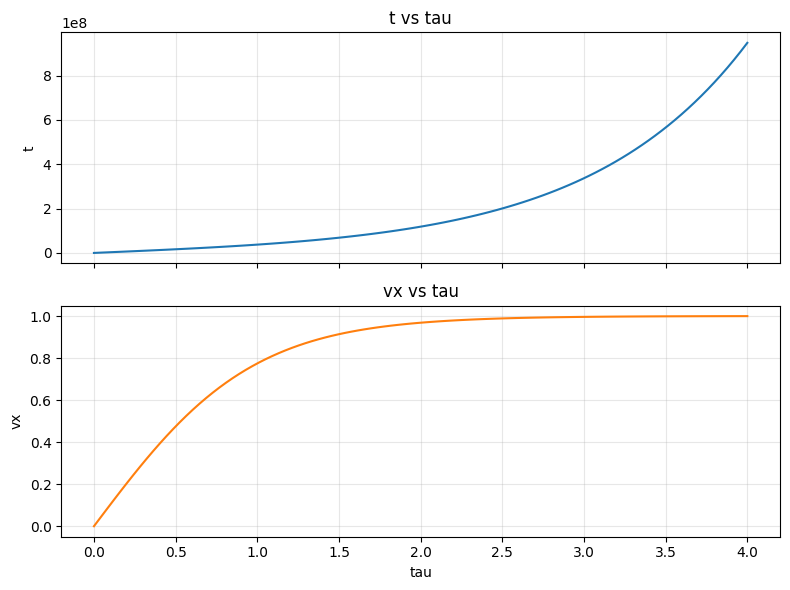

In [11]:
import matplotlib.pyplot as plt

# Resolver si aún no existe la solución
if "solucion" not in globals():
    solucion = solve_ivp(
        edm_espacio_tiempo,
        (taus[0], taus[-1]),
        Y0,
        args=(alpha,),
        t_eval=taus
    )

# Extraer variables para graficar
tau_vals = solucion.t
T_vals = solucion.y[0]
Ut_vals = solucion.y[4]
Ux_vals = solucion.y[5]

t_vals = T_vals / c
gamma_vals = Ut_vals / c
vx_vals = Ux_vals / gamma_vals

# Subplots: t vs tau y vx vs tau
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].plot(tau_vals, t_vals, color="tab:blue")
axs[0].set_ylabel("t")
axs[0].set_title("t vs tau")
axs[0].grid(True, alpha=0.3)

axs[1].plot(tau_vals, vx_vals, color="tab:orange")
axs[1].set_xlabel("tau")
axs[1].set_ylabel("vx")
axs[1].set_title("vx vs tau")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()